In [1]:
import pandas as pd
import numpy as np
import subprocess
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns


In [2]:
raw_df = pd.read_csv("../fragment_length_raw_counts.csv", index_col=0)
norm_df = pd.read_csv("../fragment_length_normalized_counts.csv", index_col=0)
qc_df = pd.read_csv("../fragment_length_qc_metrics.csv")

<Axes: >

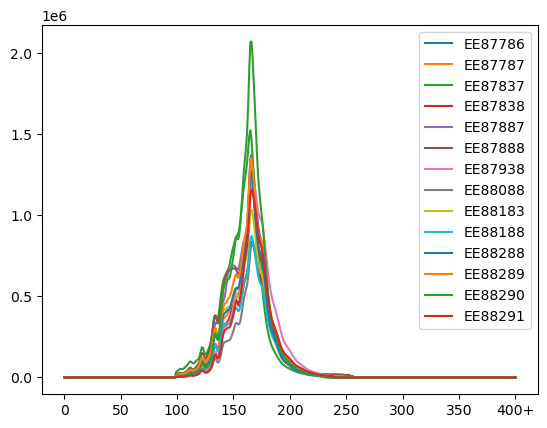

In [3]:
raw_df.T.plot()

<Axes: >

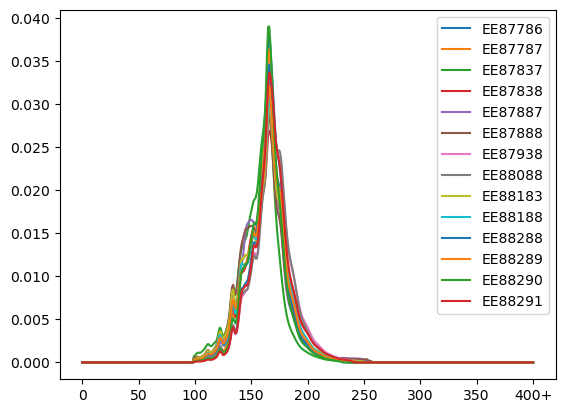

In [4]:
norm_df.T.plot()

In [5]:
qc_df


,sample,raw_fragments,filtered_fragments,ratio
0,EE87786,41493238,36201958,0.872478
1,EE87787,40397218,35072404,0.868189
2,EE87837,52911829,46074274,0.870775
3,EE87838,35857681,31061968,0.866257
4,EE87887,47550711,41677881,0.876493
5,EE87888,48431219,42394482,0.875354
6,EE87938,46462593,40533273,0.872385
7,EE88088,31217097,27137042,0.869301
8,EE88183,39875596,34715978,0.870607
9,EE88188,32893021,28642810,0.870787


In [6]:
length_cols = raw_df.columns[:-1].astype(int)
overflow_col = raw_df.columns[-1]

mean_lengths = (
    raw_df.iloc[:, :-1] * length_cols
).sum(axis=1) / raw_df.iloc[:, :-1].sum(axis=1)

mean_lengths


EE87786    165.770491
EE87787    163.733693
EE87837    157.327234
EE87838    164.767837
EE87887    162.188868
EE87888    161.145235
EE87938    168.870507
EE88088    168.056017
EE88183    162.444362
EE88188    163.603191
EE88288    162.728537
EE88289    163.154968
EE88290    163.221804
EE88291    167.583552
dtype: float64

In [7]:
short_delfi = raw_df.loc[:, :"150"].sum(axis=1)
long_delfi  = raw_df.loc[:, "151":].sum(axis=1)

ratio = short_delfi / long_delfi
ratio

EE87786    0.189969
EE87787    0.258510
EE87837    0.451672
EE87838    0.298547
EE87887    0.370136
EE87888    0.428366
EE87938    0.170798
EE88088    0.182631
EE88183    0.353116
EE88188    0.299215
EE88288    0.297170
EE88289    0.303905
EE88290    0.241566
EE88291    0.176535
dtype: float64

In [8]:
short = raw_df.loc[:, :"150"].sum(axis=1)
long  = raw_df.loc[:, "180":].sum(axis=1)

ratio_clean = short / long
ratio_clean

EE87786    1.008943
EE87787    1.502565
EE87837    4.134595
EE87838    1.145037
EE87887    2.001328
EE87888    2.124366
EE87938    0.612793
EE88088    0.680709
EE88183    1.646750
EE88188    1.373182
EE88288    1.672018
EE88289    1.504364
EE88290    1.671957
EE88291    0.751030
dtype: float64

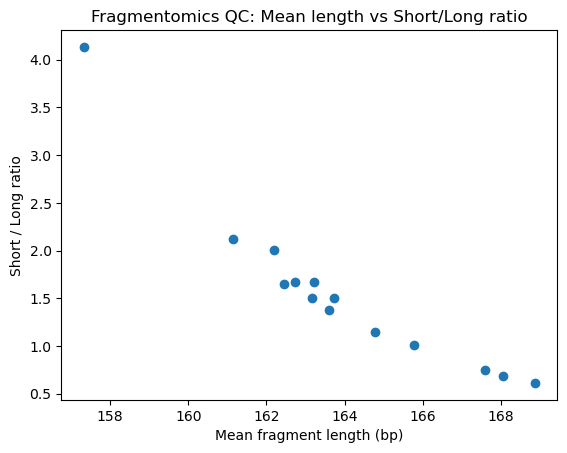

In [9]:
plt.figure()
plt.scatter(mean_lengths, ratio_clean)

plt.xlabel("Mean fragment length (bp)")
plt.ylabel("Short / Long ratio")
plt.title("Fragmentomics QC: Mean length vs Short/Long ratio")
plt.show()

In [10]:
#alleen kolommen 100-250
length_cols = raw_df.columns[:-1]
lengths= length_cols.astype(int)

mask = (lengths >= 100) & (lengths <= 250)

selected_cols = length_cols[mask] #selecteer alleen de kolommen binnen range
selected_lengths = lengths[mask] #selecteer alleen de lengtes binnen range

#filter de dataframe op basis van de geselecteerde kolommen
filtered_df = raw_df[selected_cols]


In [11]:
#normaliseren
normalized_df = filtered_df.div(filtered_df.sum(axis=1), axis=0) #deel elke waarde door de totale som van de rij

#PCA
scaled_df = StandardScaler().fit_transform(normalized_df)
pca = PCA(n_components=2) #selecteer het aantal componenten
pca_result = pca.fit_transform(scaled_df)

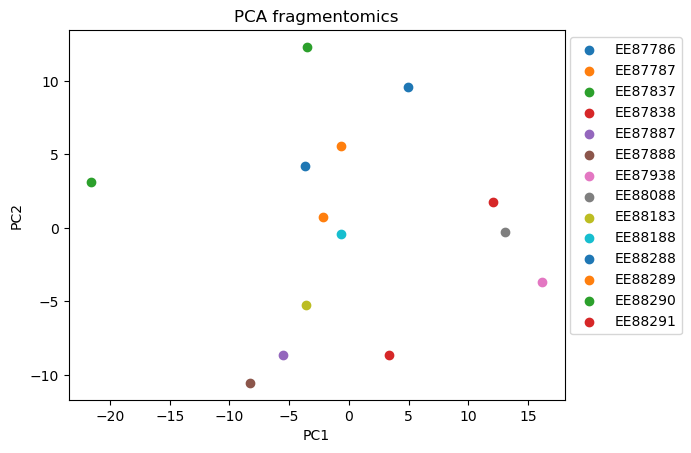

In [12]:
plt.figure()

samples = filtered_df.index

for i, sample in enumerate(samples):
    plt.scatter(
        pca_result[i, 0],
        pca_result[i, 1],
        label=sample  # legenda
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA fragmentomics")

plt.legend(bbox_to_anchor=(1.25, 1), loc='upper right')  # legenda buiten de plot
plt.show()

In [13]:
# loadings voor PC1 en PC2, welke bp range maakt PC1 en PC2
PC1 = pca.components_[0]        
PC2 = pca.components_[1]    

lengths = selected_lengths #x-as voor de loadings plot

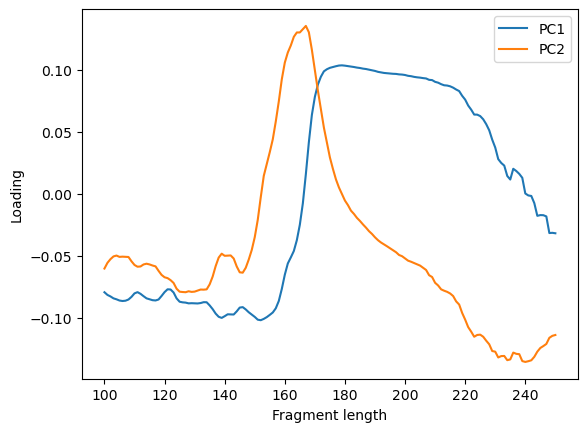

In [14]:
#plotten van de loadings
plt.figure()

plt.plot(lengths, PC1, label="PC1")
plt.plot(lengths, PC2, label="PC2")

plt.xlabel("Fragment length")
plt.ylabel("Loading")
plt.legend()

plt.show()